## Configuration for L96

In [1]:
import torch
from lorenz import Lorenz96TwoLevel
import matplotlib.pyplot as plt

params = {
    "F":8,
    "b":10,
    "h":1,
    "c":10
}

l96 = Lorenz96TwoLevel(**params)

N = 36 
J = 10
x0 = torch.randn(1,N)*0.05
y0 = torch.zeros(1,N,J)



In [2]:
T = 20
dt = 0.005
t = torch.arange(0,T,dt)
x,y = l96(T,dt,x0,y0)

In [3]:
x.shape

torch.Size([1, 4000, 36])

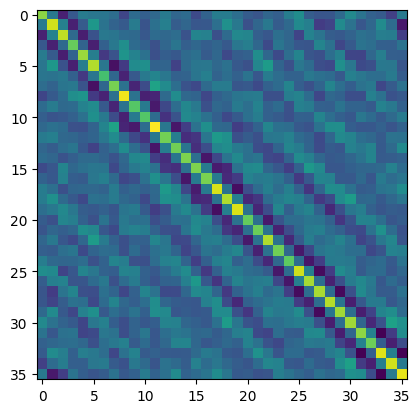

In [4]:
full_cov_matrix = torch.cov(x[0].T)
plt.imshow(full_cov_matrix.detach())
eigenvalues_full,eigenvectors_full = torch.linalg.eigh(full_cov_matrix)

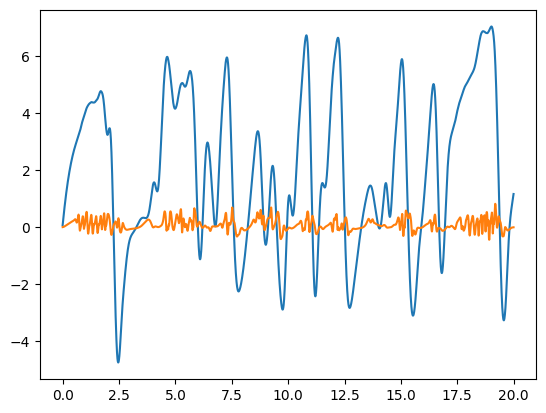

In [5]:
with torch.no_grad():
    plt.plot(t,x[0,:,0])
    plt.plot(t,y[0,:,0,0])

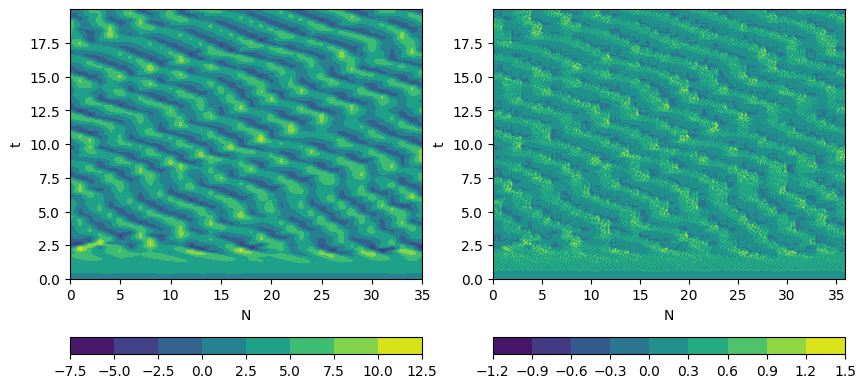

In [6]:
fig, (axX,axY) = plt.subplots(1,2,figsize=(10,5))
with torch.no_grad():
    Ns,Ts = torch.meshgrid(torch.arange(0,N).float(),t,indexing='xy')
    Nys,Tys = torch.meshgrid(torch.arange(0,N,1/J).float(),t,indexing='xy')
    xC = axX.contourf(Ns,Ts,x[0])
    yC = axY.contourf(Nys,Tys,y[0].view(-1,N*J))
    axX.set_xlabel("N")
    axX.set_ylabel("t")
    axY.set_xlabel("N")
    axY.set_ylabel("t")
    plt.colorbar(xC,orientation="horizontal",ax=axX)
    plt.colorbar(yC,orientation="horizontal",ax=axY)    



### many inputs

In [7]:
from lorenz import TimeAveragedFeatures
T = 20 
dt = 0.005
t = torch.arange(0,T,dt)

x0 = torch.randn(100,N)*0.05
y0 = torch.zeros(100,N,J)

l96_avg = TimeAveragedFeatures(l96,spinup=5,degree=1)

x_avg,y_avg = l96_avg(T,dt,x0,y0)



In [8]:
from torch.distributions import MultivariateNormal

data = MultivariateNormal(x_avg.mean(dim=0),torch.cov(x_avg.T))

In [9]:
data.covariance_matrix

tensor([[ 0.1331, -0.0075,  0.0096,  ...,  0.1172, -0.0136,  0.0192],
        [-0.0075,  0.1427, -0.0051,  ...,  0.0141,  0.1335, -0.0255],
        [ 0.0096, -0.0051,  0.1202,  ...,  0.0086,  0.0056,  0.1018],
        ...,
        [ 0.1172,  0.0141,  0.0086,  ...,  0.1388,  0.0101, -0.0043],
        [-0.0136,  0.1335,  0.0056,  ...,  0.0101,  0.1588, -0.0141],
        [ 0.0192, -0.0255,  0.1018,  ..., -0.0043, -0.0141,  0.1226]],
       dtype=torch.float64, grad_fn=<ExpandBackward0>)

### History Matching

In [10]:
x_avg_norm = (x_avg - x_avg.mean(dim=0))/x_avg.std(dim=0)
data_norm = MultivariateNormal(x_avg_norm.mean(dim=0),torch.cov(x_avg_norm.T))

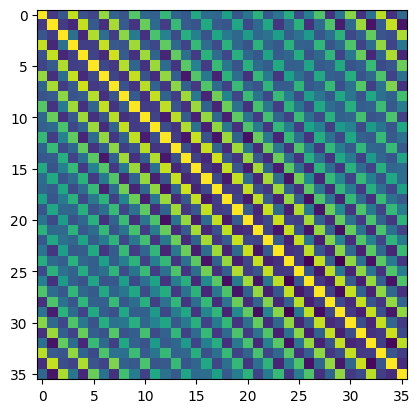

In [11]:
plt.imshow(data_norm.covariance_matrix.detach())

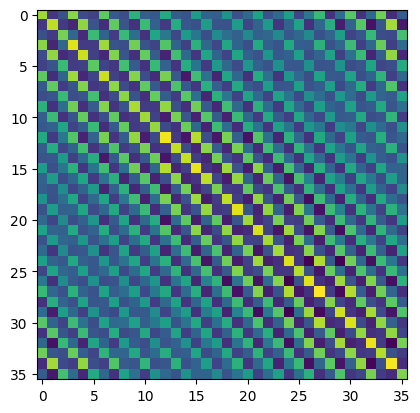

In [12]:
plt.imshow(data.covariance_matrix.detach())

In [13]:
covariance = torch.cov(x_avg.T)
eigenvalues,eigenvectors = torch.linalg.eigh(covariance)

In [14]:
eof0 =eigenvectors_full[:,-1]
pc0 = x@eigenvectors_full[:,-1]
eof1 = eigenvectors_full[:,-2]
pc1 = x@eigenvectors_full[:,-2]
eof2 = eigenvectors_full[:,-3]
pc2= x@eigenvectors_full[:,-3]

In [15]:
eigenvalues_full.numel()

36

In [16]:
recon = torch.sum(torch.stack([ torch.outer(x[0]@eigenvectors_full[:,i],eigenvectors_full[:,i]) for i in range(-1,-5,-1)]),dim=0)

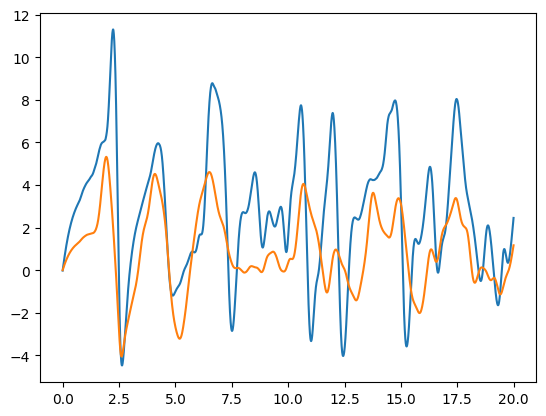

In [17]:
with torch.no_grad():
    plt.plot(t,x[0,:,1])    
    plt.plot(t,recon[:,1])  

In [18]:
from abracalibra.forward_model import ForwardModel

x0 = torch.randn(1,N)*0.05
y0 = torch.zeros(1,N,J)
T = 20
dt = 0.005

def l96(h,c,b,F):
    with torch.no_grad():
        l96 = TimeAveragedFeatures(Lorenz96TwoLevel(h=h,c=c,b=b,F=F),spinup=5,degree=1)
        x,_ = l96(T,dt,x0,y0)
        return (x[0] - x_avg.mean(dim=0))/(x_avg.std(dim=0))

fwd = ForwardModel(l96,vectorized=False)

In [19]:
from abracalibra.history_matching import HistoryMatchingBase    
from gpytorch.likelihoods import MultitaskGaussianLikelihood
from abracalibra.emulators import MultiTaskGP
from gpytorch.mlls import ExactMarginalLogLikelihood    
from gpytorch.priors import NormalPrior 

class HistoryMatchingLorenz(HistoryMatchingBase):
    def make_emulator(self, parameters, observations):
        if self.output_mc_batchshape:
            target_shape = torch.Size((*parameters.shape[:-1], *self.output_mc_batchshape, self.number_of_parameters))
            parameters = parameters.unsqueeze(-2).expand(*target_shape)
            parameters = parameters.reshape(-1, self.number_of_parameters)
        else:
            parameters = parameters.view(-1, self.number_of_parameters)
        observations = observations.view(-1, self.number_of_observables)
        likelihood = MultitaskGaussianLikelihood(
            num_tasks=self.number_of_observables,
            has_task_noise=False,
            noise_prior=NormalPrior(1,0.001)

        )
        likelihood.noise = 1 
        model = MultiTaskGP(
            parameters,
            observations,
            likelihood=likelihood,
            num_tasks=self.number_of_observables,
        ).float()
        optim = torch.optim.Adam(model.parameters(), lr=0.05)
        mll = ExactMarginalLogLikelihood(likelihood, model)
        for i in range(250):
            optim.zero_grad()
            output = model(parameters)
            loss = -mll(output, observations)
            loss.backward()
            optim.step()
            print(f"Step {i} Loss: {loss.item()}")
        model.eval()
        return model

/Users/robcking/PhD/CalibBench/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [20]:
from torch.distributions import Uniform
parameters = ['h','c','b','F']
priors = {
    'h':Uniform(0.5,4),
    'c':Uniform(5,15),
    'b':Uniform(5,15),
    'F':Uniform(5,15)
}

def summary(y,true_y):
    return torch.max(torch.abs(y.mean - true_y.mean)/torch.sqrt(y.variance + true_y.variance),dim=-1).values

hm = HistoryMatchingLorenz(parameters,priors,data,ensemble_size=80,summary=summary,forward=fwd,implausibility_cutoff=3)
hm.calibrate(1)

Step 0 Loss: 2.6610803604125977
Step 1 Loss: 2.765193462371826
Step 2 Loss: 2.5562031269073486
Step 3 Loss: 2.517204761505127
Step 4 Loss: 2.512359857559204
Step 5 Loss: 2.429403781890869
Step 6 Loss: 2.319983959197998
Step 7 Loss: 2.2421841621398926
Step 8 Loss: 2.205920696258545
Step 9 Loss: 2.175011396408081
Step 10 Loss: 2.1199307441711426
Step 11 Loss: 2.048964500427246
Step 12 Loss: 1.9864386320114136
Step 13 Loss: 1.9457353353500366
Step 14 Loss: 1.9194698333740234
Step 15 Loss: 1.8905446529388428
Step 16 Loss: 1.8511221408843994
Step 17 Loss: 1.8077846765518188
Step 18 Loss: 1.7720094919204712
Step 19 Loss: 1.7486861944198608
Step 20 Loss: 1.73226797580719
Step 21 Loss: 1.713565707206726
Step 22 Loss: 1.6895287036895752
Step 23 Loss: 1.6650012731552124
Step 24 Loss: 1.6462960243225098
Step 25 Loss: 1.6345818042755127
Step 26 Loss: 1.6253734827041626
Step 27 Loss: 1.613837480545044
Step 28 Loss: 1.5996311902999878
Step 29 Loss: 1.5863475799560547
Step 30 Loss: 1.5770838260650635

In [23]:
print(hm.nroy(torch.tensor([params['h'],params['c'],params['b'],params['F']]).float()))
hm.implausibility(torch.tensor([params['h'],params['c'],params['b'],params['F']]).float(),0)

tensor([True])


tensor([1.8234], dtype=torch.float64, grad_fn=<CatBackward0>)

In [24]:
coords = hm.get_support_axis(0,50)

In [28]:
from gpytorch.settings import fast_pred_var
H,C,B,F = torch.meshgrid(*coords,indexing='ij')
X = torch.stack([H,C,B,F],dim=-1).view(-1,4)
with torch.no_grad(),fast_pred_var():
    imp = hm.implausibility(X,0,verbose=True)

torch.no_grad() active: True
gpytorch.settings.fast_pred_var active: True


In [ ]:
imp = imp.view(H.shape)


In [ ]:
torch.save(imp,"imp_l96.pt")

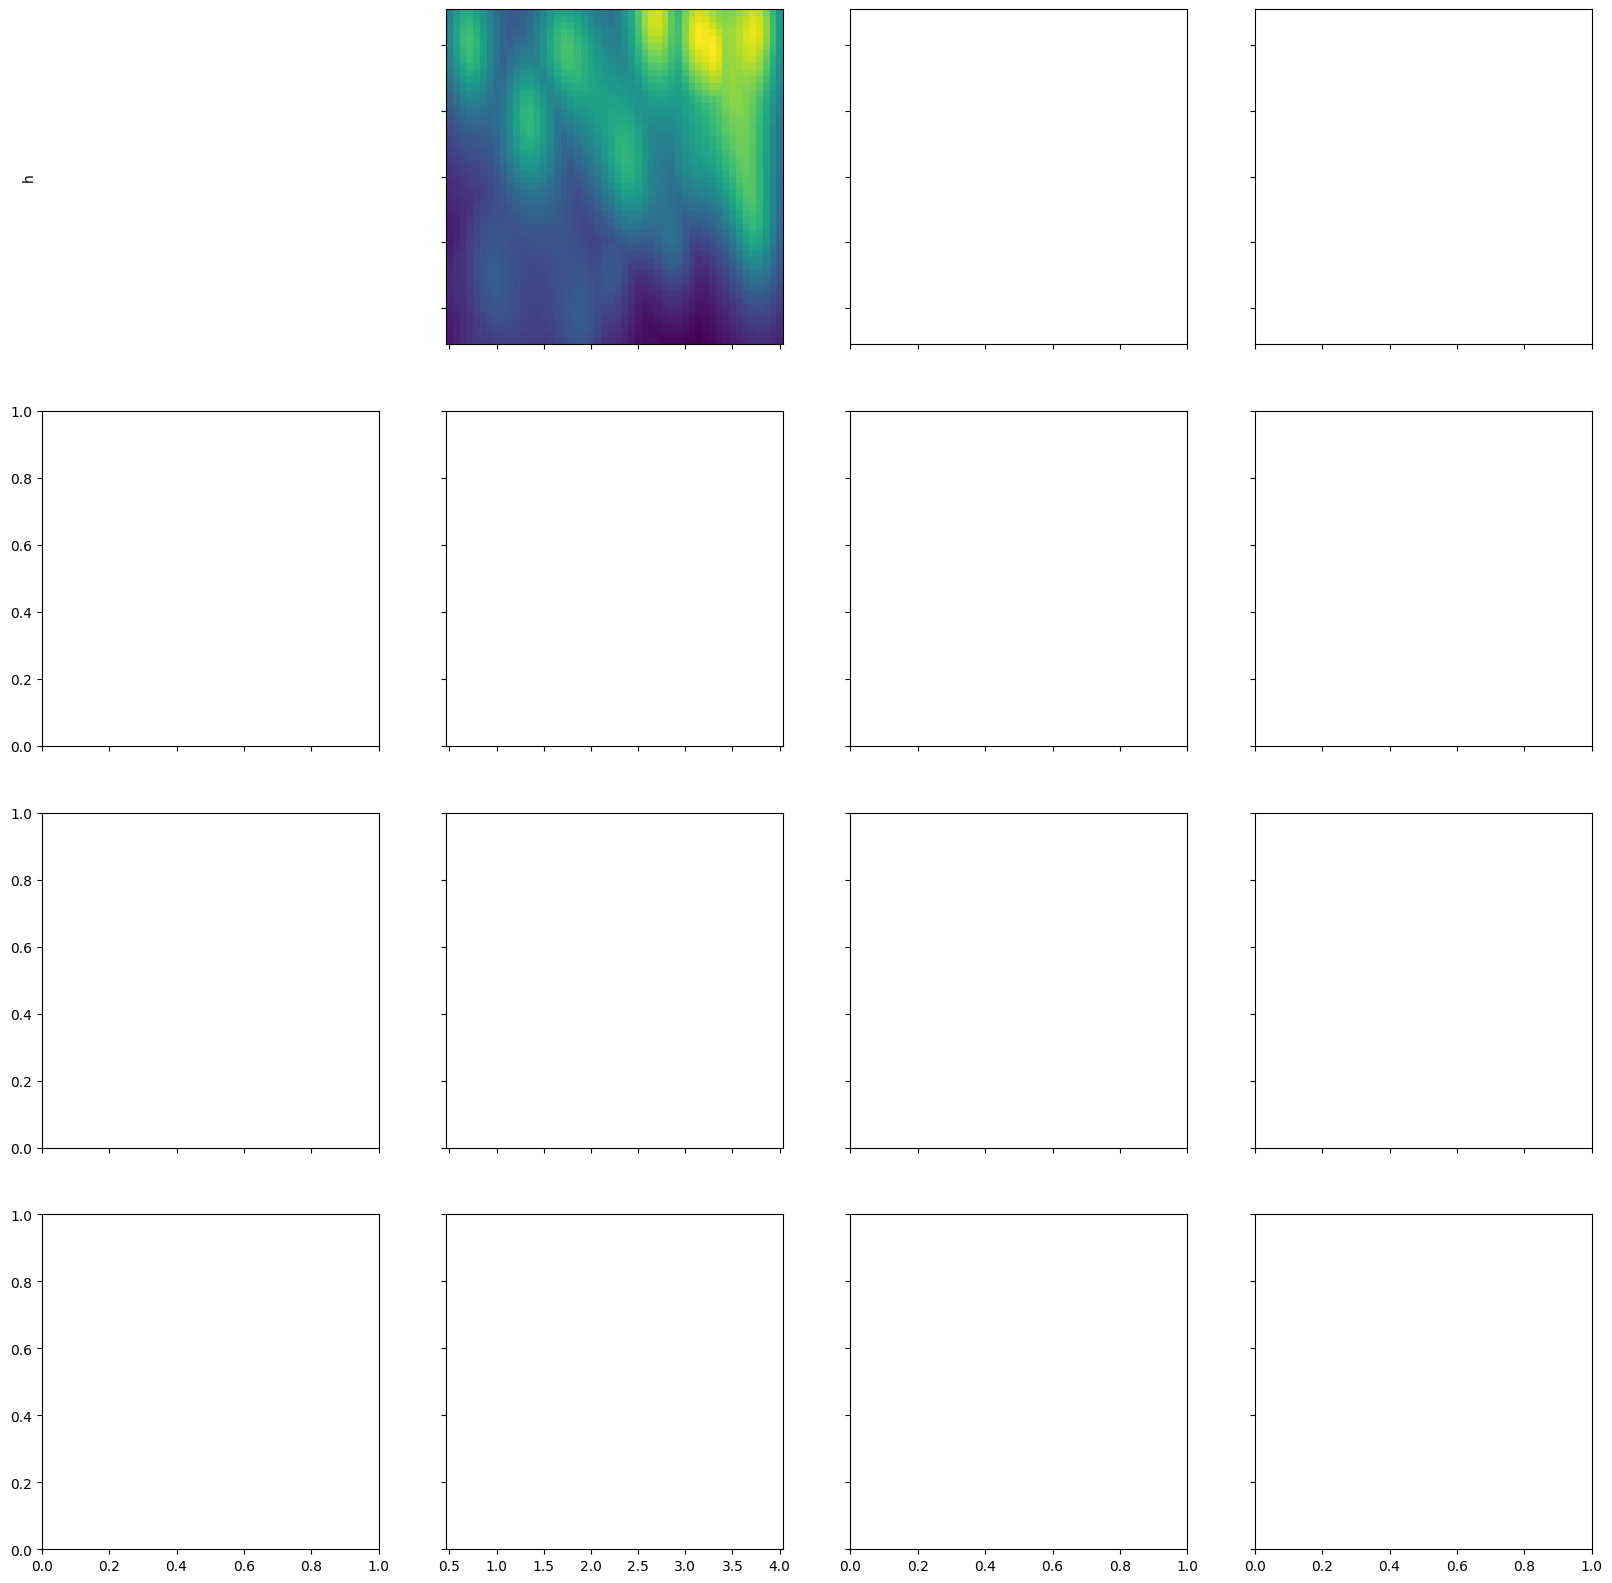

In [ ]:
fig,ax = plt.subplots(4,4,figsize=(20,20),sharex='col',sharey='row')    
for i,p1 in enumerate(coords):
    for j,p2 in enumerate(coords):
        if i == 3:
            ax[i][j].set_xlabel(hm.parameter_names[j])
        
        if j == 0:
            ax[i][j].set_ylabel(hm.parameter_names[i])
        if i == j: 
            # ax[i][j].xaxis.set_visible(False)
            ax[i][j].tick_params(left=False, labelleft=False,bottom=False,labelbottom=False)    
              # ax[i][j].yaxis.set_visible(False)
            plt.setp(ax[i][j].spines.values(), visible=False)
            continue


        values = set(range(len(coords))) - {i} - {j}
        X,Y = torch.meshgrid(p1,p2,indexing='xy')
        imp_max = torch.amax(imp,dim=tuple(values))
        ax[i][j].pcolormesh(X,Y,imp_max)
        
        break
    break

